# NBRA and non-NBRA calculations with DFTB+/Libra

In this tutorial, we will first demonstrate how the existing infrastructure/functions for DFTB+ can be used to generate the files for NBRA calculations of the dynamics. Then, a non-NBRA workflow with DFTB+/Libra will be demonstrated.

## Table of contents
<a name="toc"></a>
1. [Use in the NBRA context](#1)
2. [Non-NBRA calculations](#2)

   2.1. [Molecule](#2.1)
   
   2.2. [Initial conditions - nuclear and electronic](#2.2)
   
   2.3. [Dynamical parameters](#2.3)
   
   2.4. [Model parameters](#2.4)
   
   2.5. [Run calculations](#2.5)

   2.6. [Let's visualize some properties](#2.6)
   

### A. Learning objectives

* To execute NBRA workflow with DFTB+
* To execute non-NBRA workflow with DFTB+


### B. Use cases

* process the DFTB+ calculations results
* compute wavefunction time-overlaps with DFTB+
* NBRA workflow with DFTB+
* non-NBRA workflow with DFTB+


### C. Functions

- `libra_py`
  - `packages`
    - `dftbplus`
      - `methods`
        - [`dftb_compute_adi`](#dftb_compute_adi-1) | [`also here`](#dftb_compute_adi-2)


In [16]:
import os
import sys
import subprocess
import re
import copy
import numpy as np
from liblibra_core import MATRIX, CMATRIX, CMATRIXList, Py2Cpp_int, Cpp2Py, Random

# Fisrt, we add the location of the library to test to the PYTHON path
import libra_py.packages.dftbplus.methods as dftb
from libra_py.packages.dftbplus.methods import write_dftb_gen, \
            read_dftb_orbital_info, read_overlap_matrix, parse_tagged_file, read_nacv
from libra_py.packages.cp2k import methods as cp2k
import libra_py.citools.ci as ci
from libra_py import data_conv
from libra_py import units
import libra_py.dynamics.tsh.compute as tsh_dynamics
import libra_py.dynamics.tsh.plot as tsh_dynamics_plot



%matplotlib inline

## 1. Use in the NBRA context
<a name="1"></a>[Back to TOC](#toc)

In this example, we use a pre-computed MD trajectory for adamantane molecule. We will iterate over the trajectory snapshots and will pass the corresponding variables to `dftb_compute_adi` function (as was shown in the previous workflow). Now, we will also print the component of the excited state forces at these coordinates and the component of the NACVs (NAC vectors). All the results will be saved in the `results` folder to be (potentially) used in NBRA NA-MD calculations (not discussed explicitly).

<a name="dftb_compute_adi-1"></a>

In [17]:
os.chdir("/home/alexvakimov/CCCT/Tutorials_Libra/11_program_specific_methods/4_dftbplus_methods/4_non_nbra_workflow")
labels, q = cp2k.read_trajectory_xyz_file("adamantane.xyz", 0)

print(labels)
print(q)

dftb_params = {
    "gen_file" : "x1.gen",
    "sk_prefix" : "../mio/FinalSK/",
    "Driver" : "{}",
    "MaxAngularMomentum" : """{ C = "p"
                                H = "s"
                     }
                     """,
    "Symmetry" : "Singlet",
    "NrOfExcitations" : 5,
    "StateOfInterest" : 1,
    "WriteSPTransitions" : "Yes",
    "WriteXplusY" : "Yes",
    "WriteXplusYAscii" : "Yes",
    "StateCouplings" : "{0 5}",
    
    "WriteAutotestTag" : "Yes",
    "WriteHS" : "No",
    "WriteEigenvectors" : "Yes",
    "EigenvectorsAsText" : "Yes",
    "PrintForces" : "Yes",
    "Filling" : """Fermi { Temperature [K] = 0.5 }
                """
}

params = {"atom_labels":labels, "timestep":0, 
               "dftb_exe":"/home/alexvakimov/SOFTWARE/dftbplus/_install/bin/dftb+", 
               "dftb_run_params": dftb_params,
               "working_directory_prefix":"wd",
               
               "odin_exe": "/home/alexvakimov/SOFTWARE/odin/odin",
               "odin_max_ang_mom" : { "C":2, "H":1 },
               "orbital_space" : None,
               
               "dt":1.0*units.fs2au,
               "nelec_act_space":None,
               "ci_threshold":0.01,
               
               "act_state": {0:1},
               "is_first_time" : {0:True},
               "read_forces" : True,
               "read_nacvs": True,
              }

# Emulates 1 trajectory
full_id = Py2Cpp_int([0, 0])

res = "results"
# Create working directory, if doesn't exist
if not os.path.exists(res):
    os.mkdir(res)

# Do the first 5 steps 
for i in range(5):
    print(F"======== Iteration {i} ==============")
    labels, q = cp2k.read_trajectory_xyz_file("adamantane.xyz", i)
    params["timestep"] = i
    
    obj = dftb.dftb_compute_adi(q, params, full_id)        
    obj.ham_adi.show_matrix(F"{res}/ham_adi_{i}.txt")
    obj.hvib_adi.show_matrix(F"{res}/hvib_adi_{i}.txt")
    obj.time_overlap_adi.real().show_matrix(F"{res}/st_adi_{i}.txt")
    obj.overlap_adi.real().show_matrix(F"{res}/s_adi_{i}.txt")
    obj.d1ham_adi[0].real().show_matrix(F"{res}/forces_adi_{i}.txt")
    obj.dc1_adi[0].real().show_matrix(F"{res}/nacv_adi_{i}.txt")

['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
======== Iteration 0 ==============
DFTB+ GEN file written to wd_itraj0/x1.gen
DFTB+ GEN file written to wd_itraj0/doubled_geometry.gen
GS energy = -23.2766241727941
======== Iteration 1 ==============
DFTB+ GEN file written to wd_itraj0/x1.gen
DFTB+ GEN file written to wd_itraj0/doubled_geometry.gen
GS energy = -23.274020118486
======== Iteration 2 ==============
DFTB+ GEN file written to wd_itraj0/x1.gen
DFTB+ GEN file written to wd_itraj0/doubled_geometry.gen
GS energy = -23.2684813429252
======== Iteration 3 ==============
DFTB+ GEN file written to wd_itraj0/x1.gen
DFTB+ GEN file written to wd_itraj0/doubled_geometry.gen
GS energy = -23.2635073855038
======== Iteration 4 ==============
DFTB+ GEN file written to wd_itraj0/x1.gen
DFTB+ GEN file written to wd_itraj0/doubled_geometry.gen
GS energy = -23.260764259567


## 2. Non-NBRA calculations
<a name="2"></a>[Back to TOC](#toc)

The calculations are organized into several blocks:

1. Specification of the molecule and key variables 
2. Nuclear and electronic initial conditions
3. Defining dynamical parameters
4. Setting up the model (DFTB+) parameters
5. Running calculations
6. Plotting the results

### 2.1. Molecule
<a name="2.1"></a>[Back to TOC](#toc)

For a molecule of `N` atoms, we need:

- `labels`: chemical symbols of all atoms in the molecule (length of N)
- `coords`: coordinates of all atoms (as a 1D list with 3N elements, units: Angstrom)
- `nexcitations`: how many excited states to consider, the total number of states - `nstates` - is 1 larger than this number
- `ntraj`: how many trajectories we are going to run
- `mass_dict`: make sure to define the masses (in amu, hydrogen atom 1 amu) of all chemical species in your system

In [18]:
labels = ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 
          'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']

coords = [      9.1785800000,        5.9286800000,        6.7842300000,
           8.2887800000,        6.8273300000,        5.8957000000,
           9.1844900000,        7.7128700000,        5.0000100000,
          10.0683600000,        6.8155300000,        4.1042700000,
          10.9568600000,        5.9168300000,        4.9940500000,
           9.1608400000,        4.1444800000,        5.0000600000,
          10.0624600000,        5.0300200000,        5.8898200000,
           7.3884800000,        5.9404800000,        5.0058800000,
           8.2710700000,        5.0418400000,        4.1102000000,
           9.1667500000,        5.9287100000,        3.2157700000,
           8.5418210000,        5.2981400000,        7.4430300000,
           9.8197100000,        6.5592600000,        7.4387600000,
           7.6533400000,        7.4733510000,        6.5396200000,
           8.5520100000,        8.3737900000,        4.3673800000,
           9.8257000000,        8.3652800000,        5.6327100000,
          10.7122700000,        7.4531000000,        3.4603400000,
          11.6198800000,        6.5472000000,        5.6265800000,
          11.6071300000,        5.2777000000,        4.3570700000,
           9.7891300000,        3.4835800000,        4.3632500000,
           8.5238300000,        3.4920700000,        5.6369700000,
          10.7021300000,        4.3839800000,        6.5295200000,
           6.7297000000,        5.3100700000,        5.6427900000,
           6.7339500000,        6.5795900000,        4.3732500000,
           7.6229200000,        4.4042900000,        3.4705200000,
           9.7951300000,        5.2897900000,        2.5569900000,
           8.5340190000,        6.5676900000,        2.5612300000
    ]

ndof = len(coords)

q = [x*units.Angst for x in coords ]

p = [0.0 for _ in range(ndof)]

mass = []
mass_dict = {"C":12.0, "H":1.0 }
for elt in labels:
    m = mass_dict[elt] * units.amu
    mass.append(m)
    mass.append(m)
    mass.append(m)

print(F"ndof = {ndof}")
nat = len(labels)
print(F"nat = {nat}")


nexcitations = 5
nstates = nexcitations + 1
ntraj = 2

ndof = 78
nat = 26


### 2.2. Initial conditions - nuclear and electronic
<a name="2.2"></a>[Back to TOC](#toc)

**Nuclear parameters**
- `ndof`: the number of degrees of freedom (3N) - defined above
- `q`: average positions of coordinates (Bohr) - defined above
- `p`: average momenta - defined above
- `mass`: masses of all DOFs - defined above
- `init_type = 4`: defined q and p spread manually
- `q_width` and `p_width`: set up some reasonable values

--- 

**Electronic parameters**

- `istate = 2`: initial electronic state
- `rep = 1`: initial states are chosen as adiabatic
- `init_type = 1` : initialize random phases of non-zero electronic amplitudes

In [19]:
############################################################
### 1. Choose the initial conditions: Nuclear and Electronic
############################################################

# Nuclear initial conditions 
nucl_params = { "ndof":ndof,
                "q":q, "p":p,
                "mass":mass,
                "force_constant":[ 0 for _ in range(ndof) ],
                "q_width":[ 0.1 for _ in range(ndof)  ],
                "p_width":[ 0.1 for _ in range(ndof)  ],
                "init_type": 4
              }

# Electronic initial conditions - start on the second adiabatic state (starting from 0 = ground)
##########
istate = 2
##########
istates = [0.0 for i in range(nstates)]
istates[istate] = 1.0     
elec_params = {"verbosity":2, "init_dm_type":0,"ndia":nstates, "nadi":nstates, 
               "rep":1, "init_type":1, "istates":istates, "istate":istate     }

### 2.3. Dynamical parameters
<a name="2.3"></a>[Back to TOC](#toc)

- `nsteps = 5` : for how many steps to integrate the dynamics
- `ntraj` : how many trajectories - defined above
- `nstates` : how many electronic states - defined above

**IMPORTANT: many essential parameters are loaded from the `recipes/fssh2.py`, which is taylored for this kind of workflow**

> this is not a generic recipe for model-based calculations. In this case, the recipe is desgned to read adiabatic properties and avoid obtaining adiabatic properties from the diabatic (which are not given)

In [20]:
###########################################################
### 2. Dynamics parameters
###########################################################

dyn_general = { "nsteps":20, "ntraj":ntraj, "nstates":nstates,
                "dt":0.5*units.fs2au, "num_electronic_substeps":1, "isNBRA":0, "is_nbra":0,
                "progress_frequency":0.5, "which_adi_states":range(nstates), "which_dia_states":range(nstates),
                "mem_output_level":3,
                "properties_to_save":[ "timestep", "time", "q", "p", "f", "Cadi", "Cdia", "Epot_ave", "Ekin_ave", "Etot_ave",
                "states", "se_pop_adi", "se_pop_dia", "sh_pop_adi", "sh_pop_dia"],
                "prefix":"adiabatic_md", "prefix2":"adiabatic_md"
              }

from recipes import fssh2

fssh2.load(dyn_general) # FSSH2

### 4. Model parameters
<a name="2.4"></a>[Back to TOC](#toc)

This is probably the most non-trivial section for this kind of calculations. Let's discuss some key parameters:

This code should not be necessary, in general, but I do it to force a consistent start of calculations if previous calculations broke down and the system got stuck in a different working directory:

    os.chdir("/home/alexvakimov/CCCT/Tutorials_Libra/11_program_specific_methods/4_dftbplus_methods/4_non_nbra_workflow")
    
    
- `model_params["atom_labels"]`: atomic labels defined above
- `model_params["timestep"]` : doesn't really matter for this calculation (only used in NBRA workflows)
- `model_params["dftb_exe"]`: path to the DFTB+ executable
- `model_params["dftb_run_params"]` : the parameters and templates for generating input file for DFTB+ calculations (`dftb_in.hsd`). We'll discuss them in more details below.
- `model_params["working_directory_prefix"]` : the common name of the working directories. For each trajectory, a directory will be created (indexed with the index of the trajectory and having the same prefix defined by this parameter). Each directory will contain the files generated for that particular trajectory.
- `model_params["odin_exe"]` : path to the ODIN executable
- `model_params["odin_max_ang_mom"]` : dictionary defining what max angular momentum is assumed for atom of each kind - used in ODIN calculations of the AO time-overlaps. Should be consistent with `dftb_params["MaxAngularMomentum"]`
- `model_params["orbital_space"]` : potentially list all the MO indices to handle explicitly (if None - all the MO indices will be used)
- `model_params["nelec_act_space"]` : how many electrons in the occupied orbitals to consider when constructing Slater determinants. Should be "deep" enough to include all the essential excited Slater determinants. 
- `model_params["ci_threshold"]` : include only those excited Slater determinants in the CI expansion whose amplitudes are larger in absolute values than this threshold. This helps to reduce the number of needed CI configurations quite dramatically. 
- `model_params["dt"]` : nuclear and electronic integration timestep
- `model_params["act_state"]` : the dictionary defining the active states for each trajectory. The key is the trajectory index, the value is the state index 
- `model_params["is_first_time"]` : the dictionary defining the pre-existing computations state for each trajectory. Should be "True" initially. The key of the dictionary is the trajectory index, the value is the status. It will be updated to "False" as soon as the previous calculations are completed.
- `model_params["read_forces"]` : whether the workflow should attempt to read the forces (not needed for NBRA calculations)
- `model_params["read_nacvs"]` : whether the workflow should attempt to read the NAC vectors (not needed for NBRA calculations)

The following 3 are particularly needed for the TSH calculations in `generic_recipe` work
- `model_params["model0"]` : doesn't matter the value, since it is not currently used, but should be present
- `model_params["model"]` : doesn't matter the value, since it is not currently used, but should be present
- `model_params["nstates"]` : the total number of states (including the ground state) - should have been defined above.

Next, let's consider the parameters of the `model_params["dftb_run_params"]`:

- `gen_file` : the name of the .gen file that will be generated in the folder for each trajectory and for each time-step and will contain the geometry information for that trajectory and timestep
- `sk_prefix` : the folder containing the Slater-Koster (SK) files (correctly generated, so they work for ODIN!) relative to each trajectory's working directory. Say, we are in the rood directory "X" from which the calculations are started. Say this folder contains the SK files - in the `X/mio/FinalSK/` folder. If `model_params["working_directory_prefix"] = "non_nbra_wd"`, then the folders `X/non_nbra_wd_itraj0`, `X/non_nbra_wd_itraj1`, `X/non_nbra_wd_itraj2`, etc. will be created. In each, there will be the `dftb_in.hsd` file that will be pointing to the SF files directory. Considering our assumed file systems, it should be `../mio/FinalSK/` 
- `Driver` : add any extra instructions there for the DFTB+ calculations (consult with the DFTB+ manual for that section)
- `MaxAngularMomentum` : max angular momenta for each atom, defining the corresponding basis. Should be consistent with `model_params["odin_max_ang_mom"]`
- `Symmetry` : Singlet, Triplet, both, etc. Currently, only singlets are supported
- `NrOfExcitations` : how many excitations to compute - should have been defined above - see the `nexcitations` variable
- `StateOfInterest` : index of the electronic state for which properties (e.g. forces) will be computed. Only works for the excited states. If set to 0 (ground state) - the forces will be extracted from the ground-state calculations. In the non-NBRA workflow, it doesn't matter which index we assign to this variable - it will be updated internally during the calculations.  
- `WriteSPTransitions` : print single-particle excitations basis
- `WriteXplusY` : write the X+Y coefficients from TD-DFTB calculations (amplitudes)
- `WriteXplusYAscii` : write them as text - should be fine for small systems. The binary storage is possible, but is not yet fully-included in the workflow.
- `StateCouplings` : for which range of state pairs we compute NACVs. {0, 2} would be 0-1, 0-2, 1-2, etc. The upper value should be set to `nexcitations`
- `WriteAutotestTag` : is needed to getting properties in a convenient way
- `WriteHS` : No - we don't need, since the time-overlaps are computed with ODIN
- `WriteEigenvectors` : we print MOs 
- `EigenvectorsAsText` : we print them as text (binary option is also possible, but not yet included)
- `PrintForces` : we need excited state (or ground-state) forces
- `Filling` : make sure the temperature is low enough to avoid significant fractional occupations since the TD-DFT may break down in that case

In [21]:
###########################################################
### 3. Model parameters
###########################################################
os.chdir("/home/alexvakimov/CCCT/Tutorials_Libra/11_program_specific_methods/4_dftbplus_methods/4_non_nbra_workflow")
wd = "non_nbra_wd"

# Create working directory, if doesn't exist
if not os.path.exists(wd):
    os.mkdir(wd)

dftb_params = {
    "gen_file" : "x1.gen",
    "sk_prefix" : "../mio/FinalSK/",
    "Driver" : "{}",
    "MaxAngularMomentum" : """{ C = "p"
                                H = "s"
                     }
                     """,
    "Symmetry" : "Singlet",
    "NrOfExcitations" : nexcitations,
    "StateOfInterest" : 1,
    "WriteSPTransitions" : "Yes",
    "WriteXplusY" : "Yes",
    "WriteXplusYAscii" : "Yes",
    "StateCouplings" : "{0 5}",
    
    "WriteAutotestTag" : "Yes",
    "WriteHS" : "No",
    "WriteEigenvectors" : "Yes",
    "EigenvectorsAsText" : "Yes",
    "PrintForces" : "Yes",
    "Filling" : """Fermi { Temperature [K] = 0.5 }
                """
}

model_params = {"atom_labels":labels, "timestep":0, 
               "dftb_exe":"/home/alexvakimov/SOFTWARE/dftbplus/_install/bin/dftb+", 
               "dftb_run_params": dftb_params,
               "working_directory_prefix":"non_nbra_wd",
               
               "odin_exe": "/home/alexvakimov/SOFTWARE/odin/odin",
               "odin_max_ang_mom" : { "C":2, "H":1 },
               "orbital_space" : None,
               
               "dt":0.5*units.fs2au,
               "nelec_act_space":None,
               "ci_threshold":0.01,
               
               "act_state": { i:istate for i in range(ntraj) },
               "is_first_time" : { i:True for i in range(ntraj) },
               
               "read_forces" : True,
               "read_nacvs": True,
               
               "nstates": nstates,
                "model": 0,
                "model0": 0
              }


### 5. Run calculations
<a name="2.5"></a>[Back to TOC](#toc)

This part is the same as for model calculations, but notice that instead of passing some model Hamiltonian function, we use `dftb.dftb_compute_adi` function
<a name="dftb_compute_adi-2"></a>

In [22]:
dyn_params = dict(dyn_general)
pref = "FSSH2_"
dyn_params.update({ "prefix":pref, "prefix2":pref })
print(F"Computing {pref}")    

rnd = Random()
res = tsh_dynamics.generic_recipe(dyn_params, dftb.dftb_compute_adi, model_params, elec_params, nucl_params, rnd)

Computing FSSH2_
tanglement_opt is not defined! in the input parametersUse the default value 
In cctor: lvl = 1 der_lvl = 2
[2, 2]
Initial adiabatic populations
[0.0, 0.0, 1.0, 0.0, 0.0, 0.0]
not defined! in the input parametersUse the default value 
======= Initialization type is 1 ========
setting representation 1 coefficient to complex C_2 such that |C_2}|^2 = 1.0
======= Initialization type is 1 ========
setting representation 1 coefficient to complex C_2 such that |C_2}|^2 = 1.0
========== ampl_dia ===============
(0.0000000,0.0000000)  (0.0000000,0.0000000)  
(0.0000000,0.0000000)  (0.0000000,0.0000000)  
(0.0000000,0.0000000)  (0.0000000,0.0000000)  
(0.0000000,0.0000000)  (0.0000000,0.0000000)  
(0.0000000,0.0000000)  (0.0000000,0.0000000)  
(0.0000000,0.0000000)  (0.0000000,0.0000000)  

========== ampl_adi ===============
(0.0000000,0.0000000)  (0.0000000,0.0000000)  
(0.0000000,0.0000000)  (0.0000000,0.0000000)  
(-0.63450543,-0.77291840)  (0.98324038,-0.18231389)  
(0.00000

GS energy = -23.1735035739158
DFTB+ GEN file written to non_nbra_wd_itraj1/x1.gen
DFTB+ GEN file written to non_nbra_wd_itraj1/doubled_geometry.gen
GS energy = -23.1670782040562
Saving data for step  0
 step= 0
DFTB+ GEN file written to non_nbra_wd_itraj0/x1.gen
DFTB+ GEN file written to non_nbra_wd_itraj0/doubled_geometry.gen
GS energy = -23.1749770071932
DFTB+ GEN file written to non_nbra_wd_itraj1/x1.gen
DFTB+ GEN file written to non_nbra_wd_itraj1/doubled_geometry.gen
GS energy = -23.1692328474413
Saving data for step  1
DFTB+ GEN file written to non_nbra_wd_itraj0/x1.gen
DFTB+ GEN file written to non_nbra_wd_itraj0/doubled_geometry.gen
GS energy = -23.1787807337012
DFTB+ GEN file written to non_nbra_wd_itraj1/x1.gen
DFTB+ GEN file written to non_nbra_wd_itraj1/doubled_geometry.gen
GS energy = -23.1737679323897
Saving data for step  2
DFTB+ GEN file written to non_nbra_wd_itraj0/x1.gen
DFTB+ GEN file written to non_nbra_wd_itraj0/doubled_geometry.gen
GS energy = -23.183530348769
DF

### 6. Let's visualize some properties 
<a name="2.6"></a>[Back to TOC](#toc)

Again, we can re-use the plotting functions used for model Hamiltonians, although some more post-processing will be needed to generate the MD trajectories of the systems evolving in their excited-state

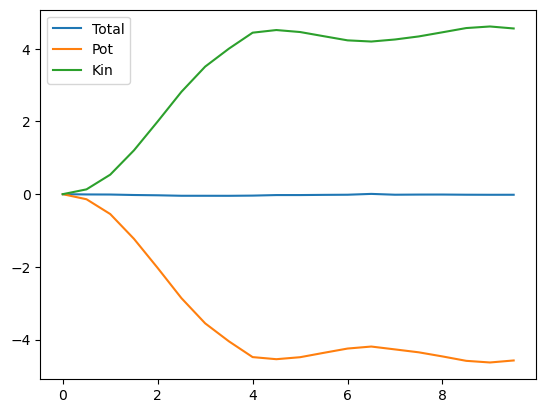

In [25]:
import h5py 
import matplotlib.pyplot as plt
%matplotlib inline

with h5py.File("FSSH2_/mem_data.hdf", 'r') as f:
    t = f["time/data"][:]
    energy = f["Etot_ave/data"][:] - f["Etot_ave/data"][0]
    epot = f["Epot_ave/data"][:] - f["Epot_ave/data"][0]
    ekin = f["Ekin_ave/data"][:] - f["Ekin_ave/data"][0]    
    
    plt.plot(t * units.au2fs, energy * units.au2ev, label="Total")
    plt.plot(t * units.au2fs, epot * units.au2ev, label="Pot")
    plt.plot(t * units.au2fs, ekin * units.au2ev, label="Kin")
    
    plt.legend()
    plt.show()

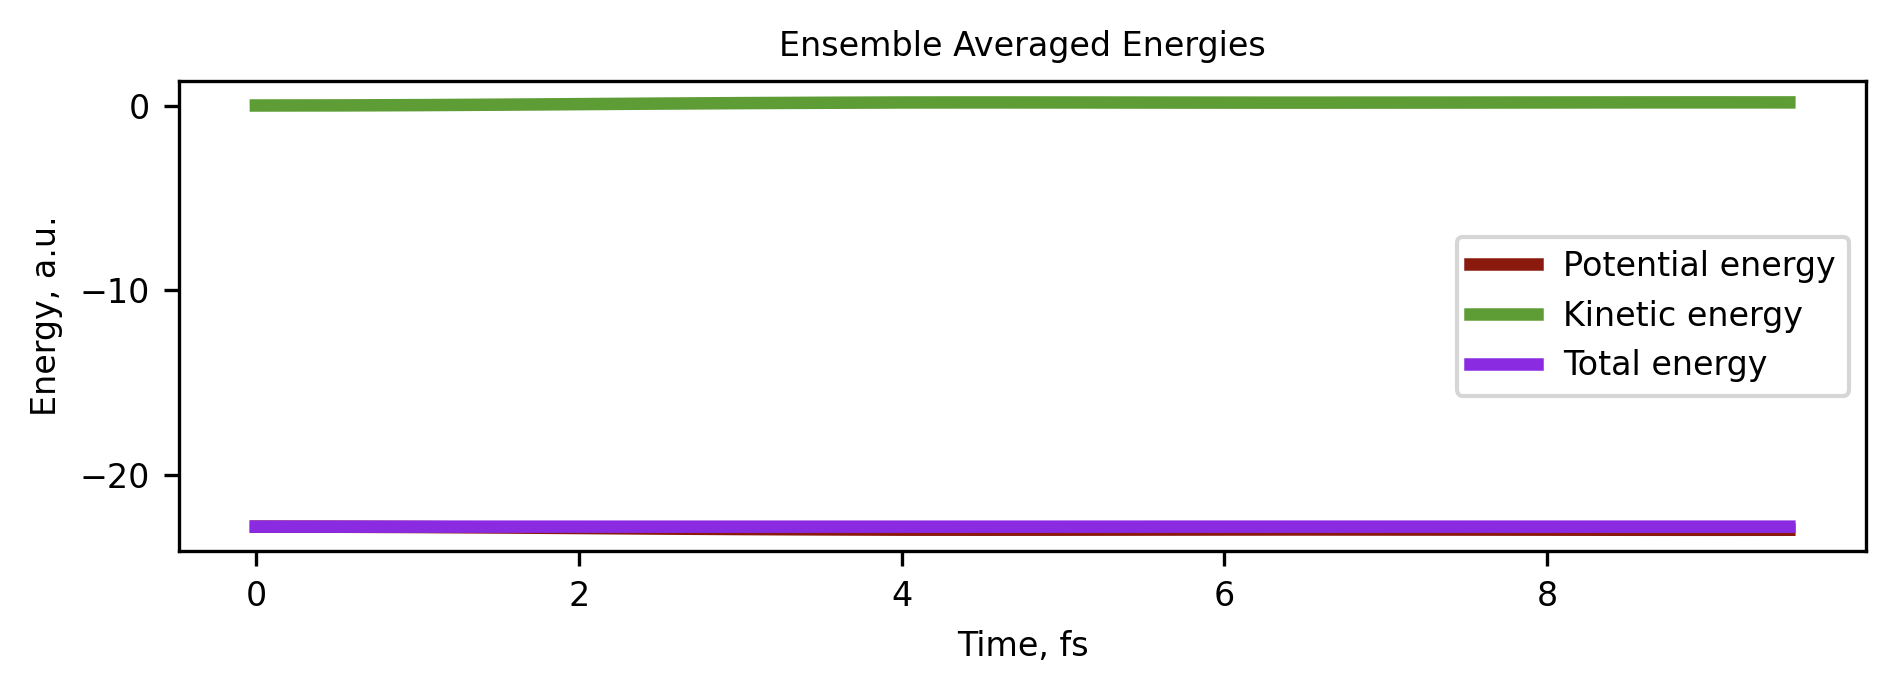

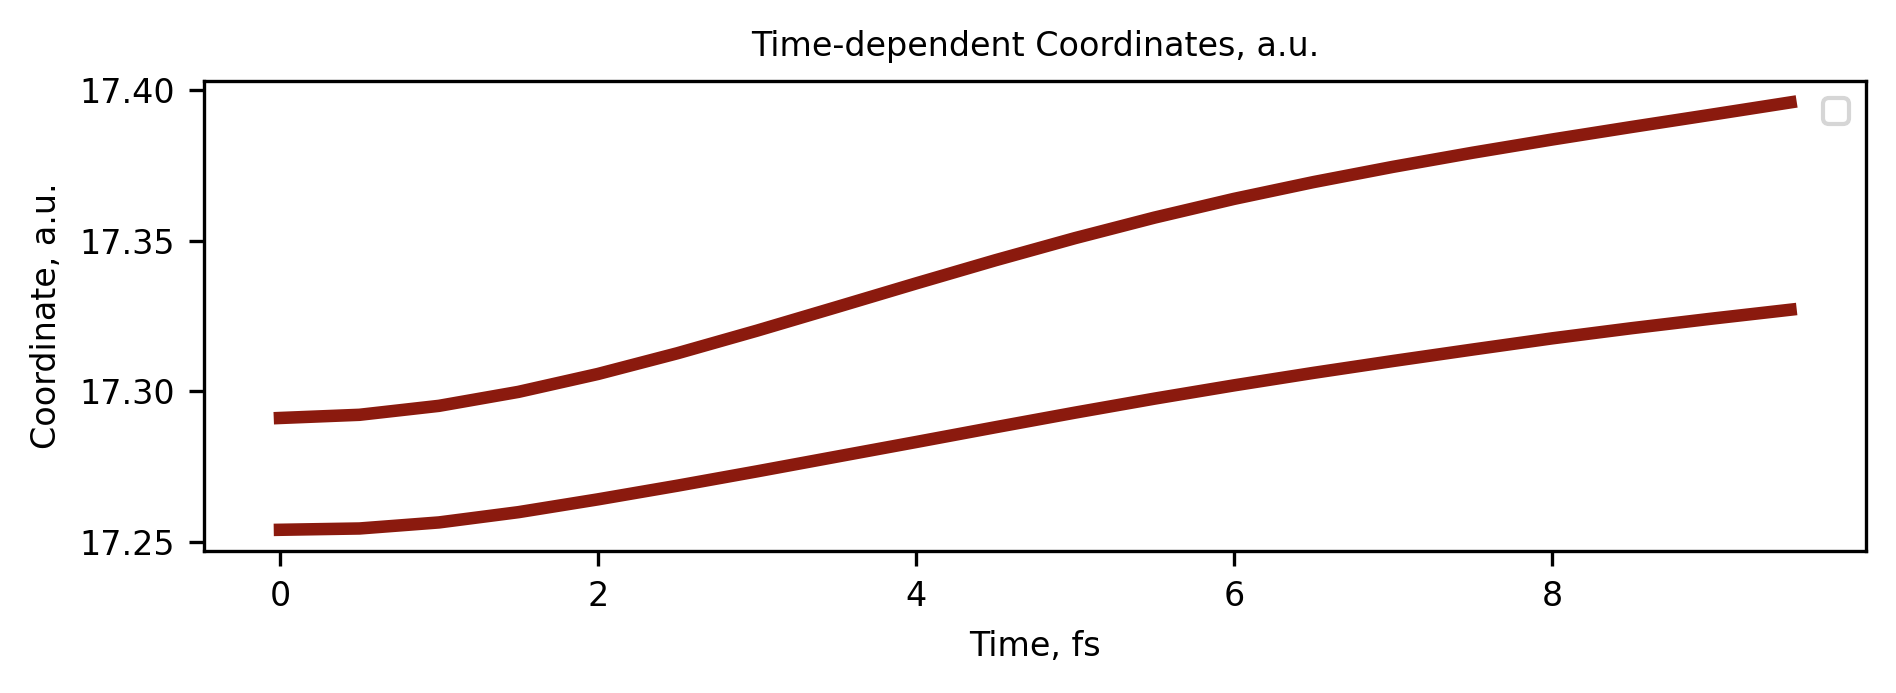

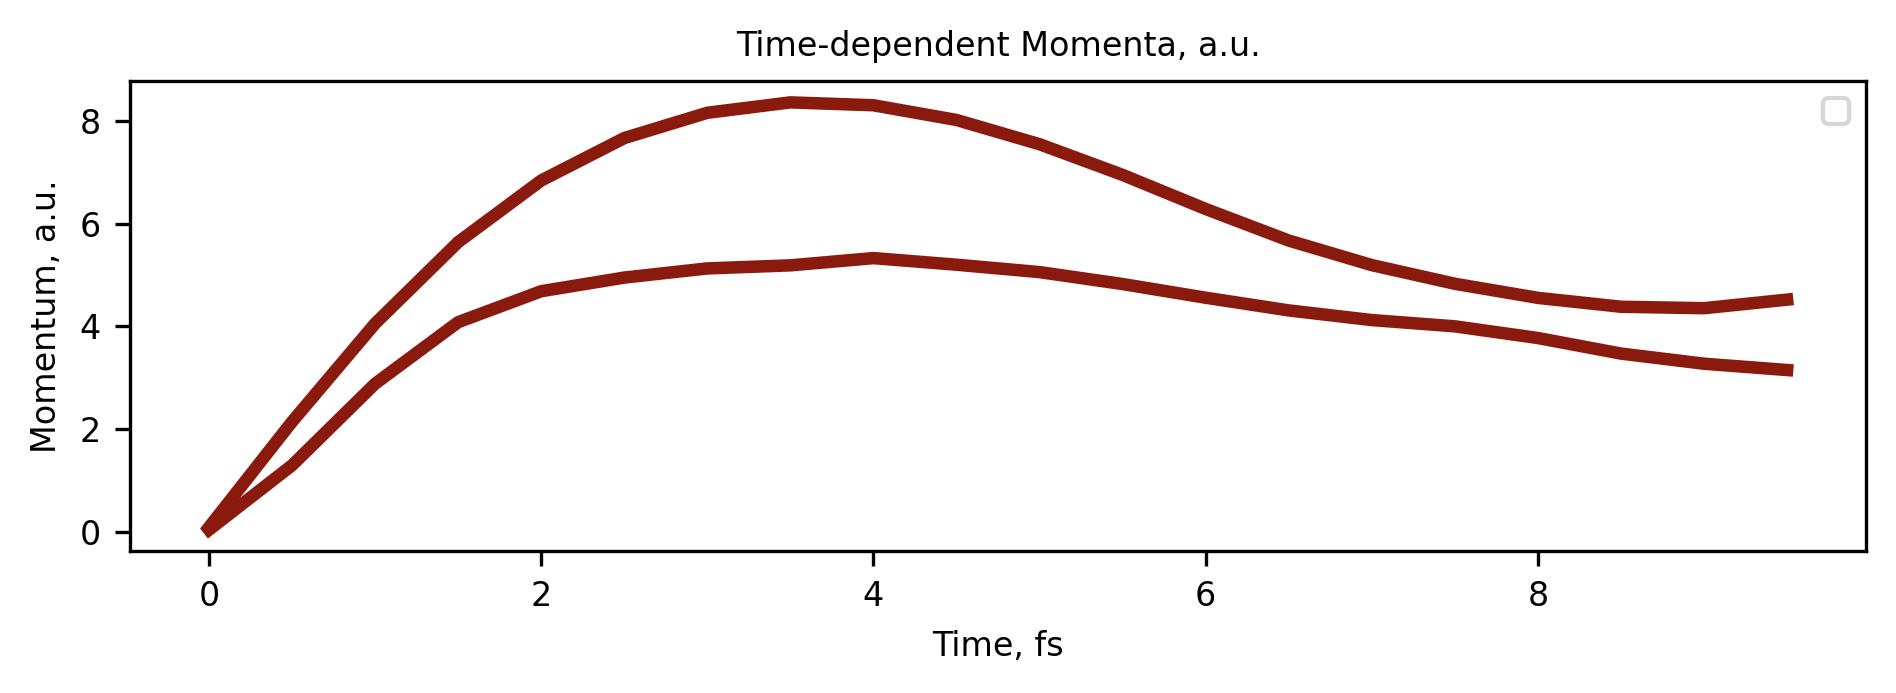

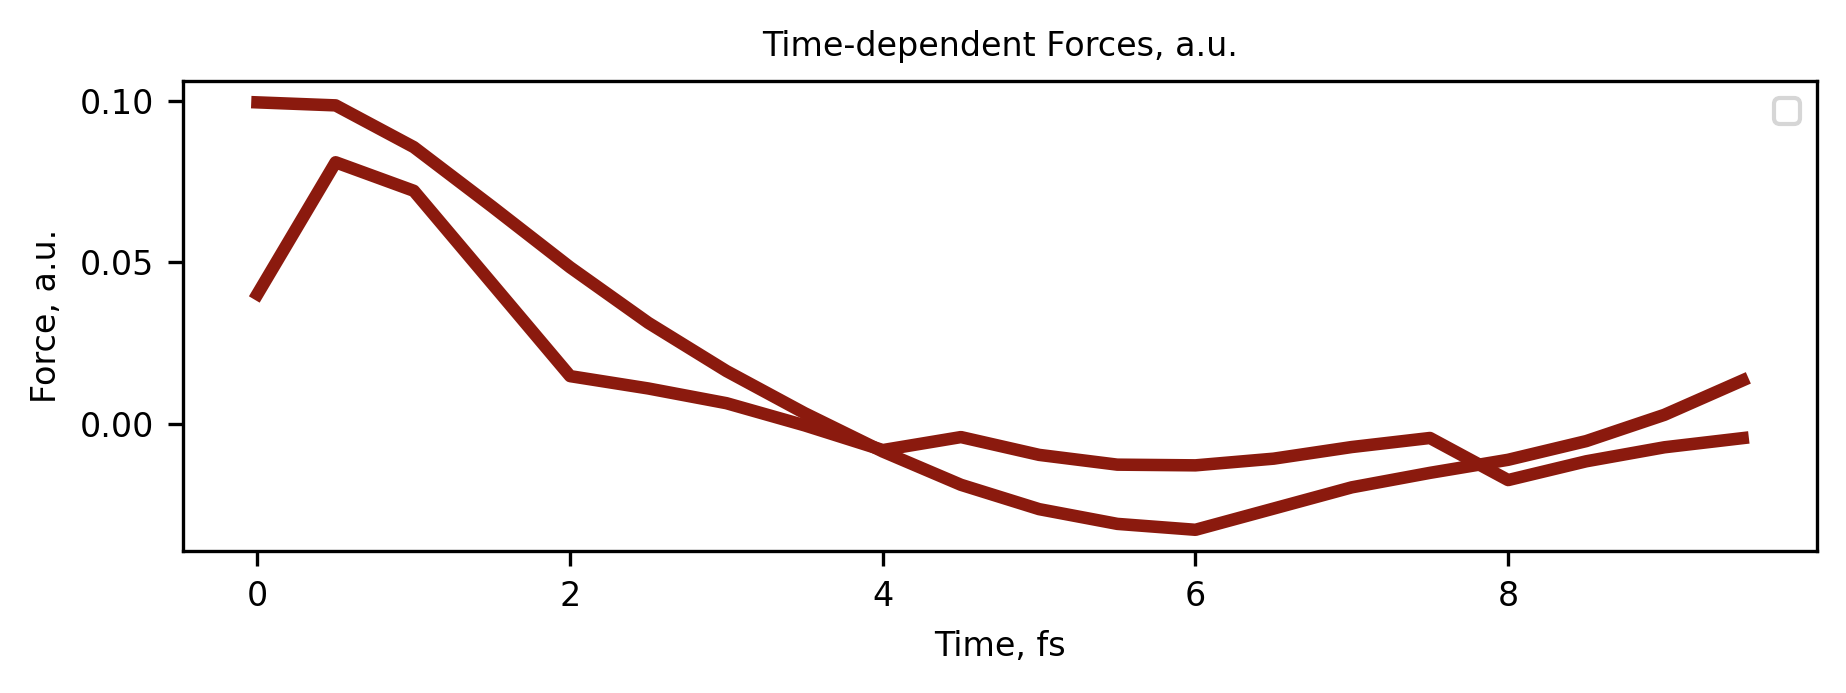

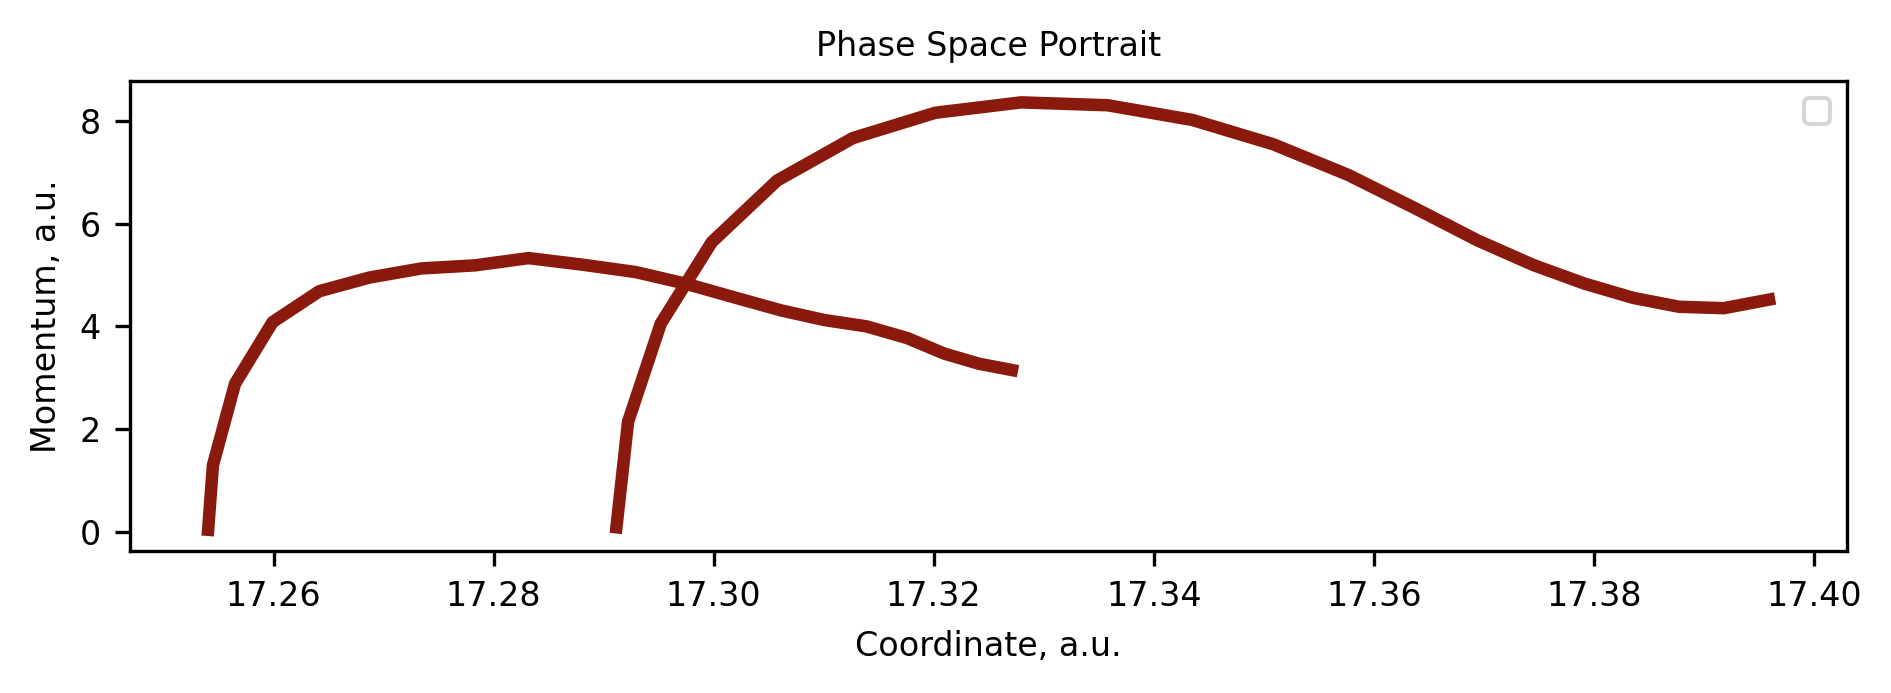

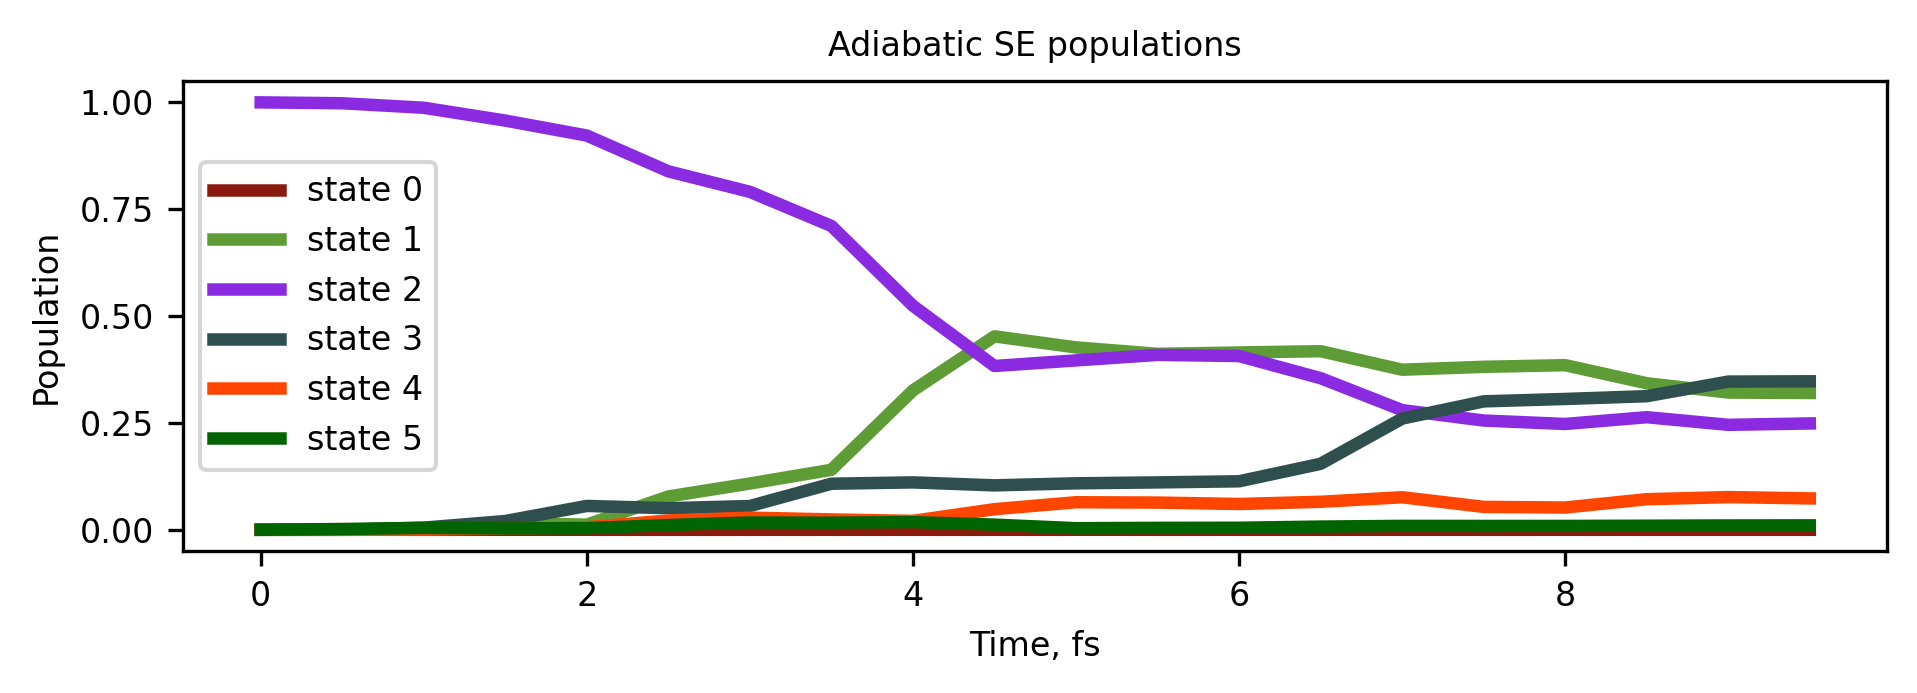

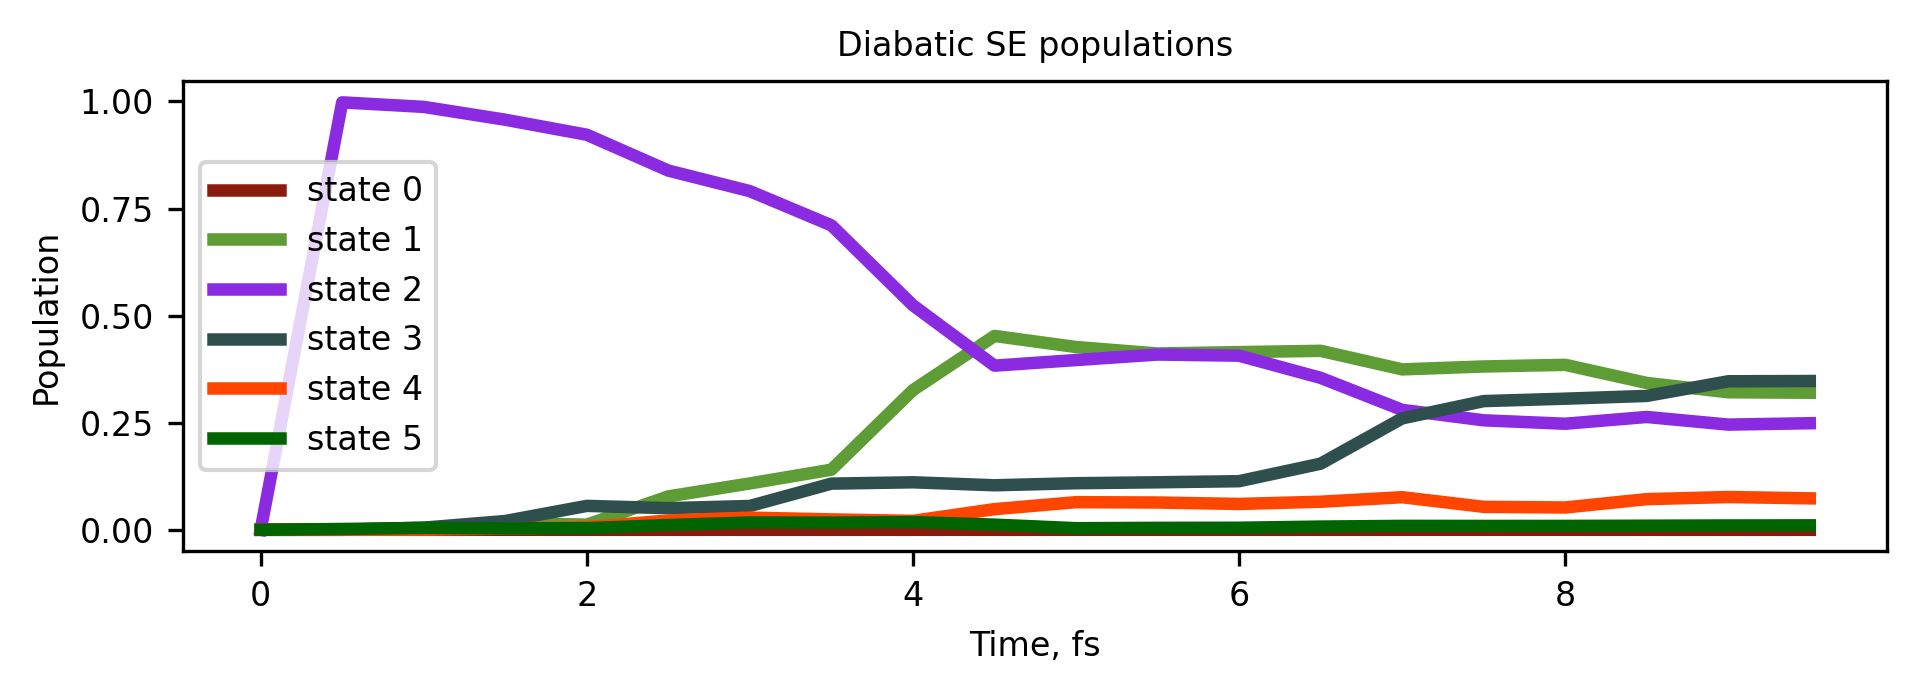

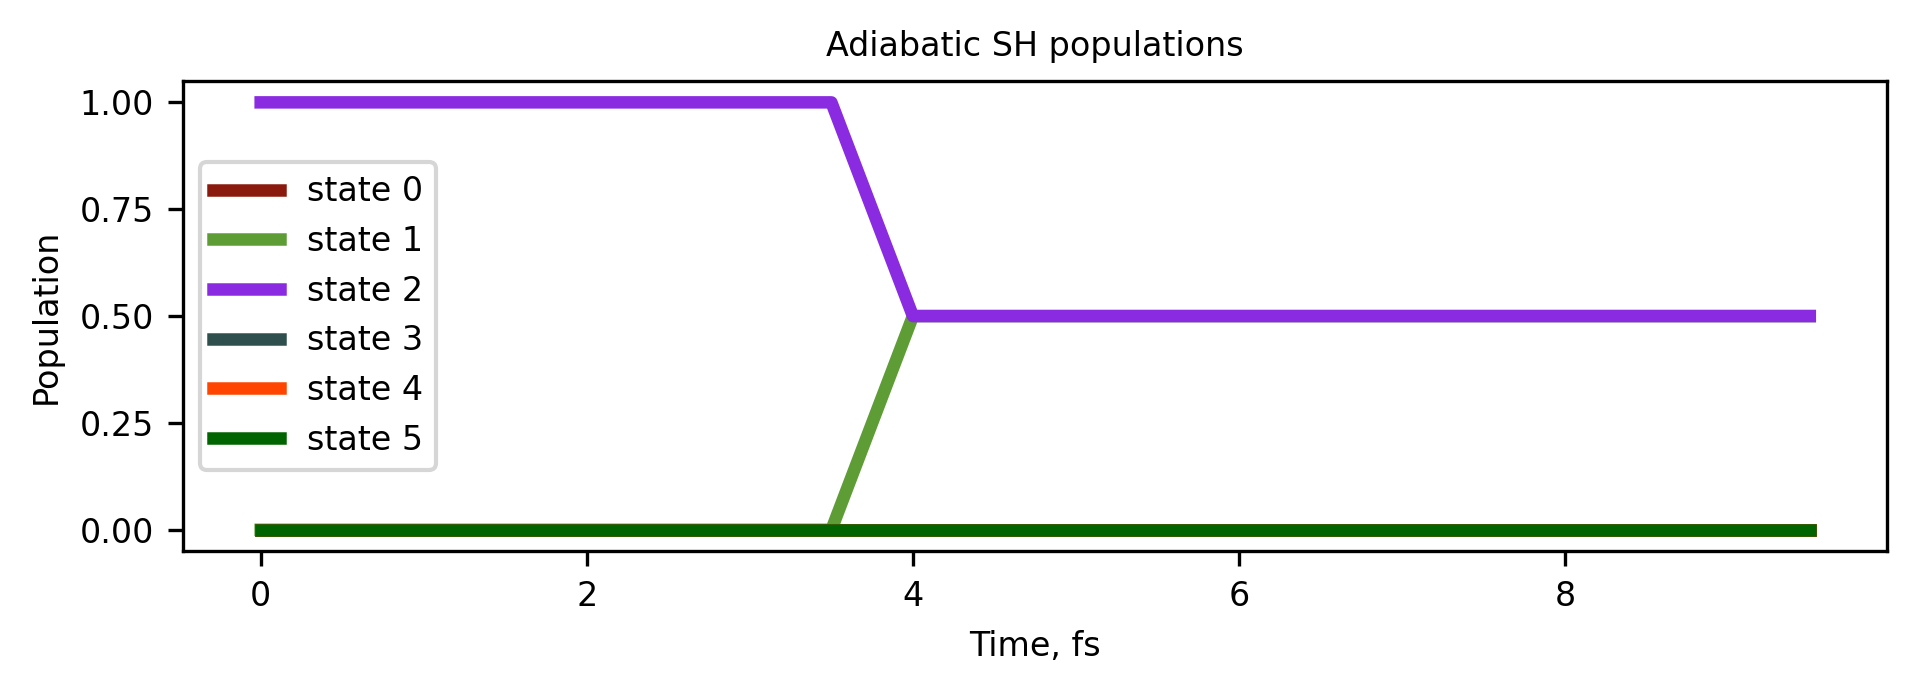

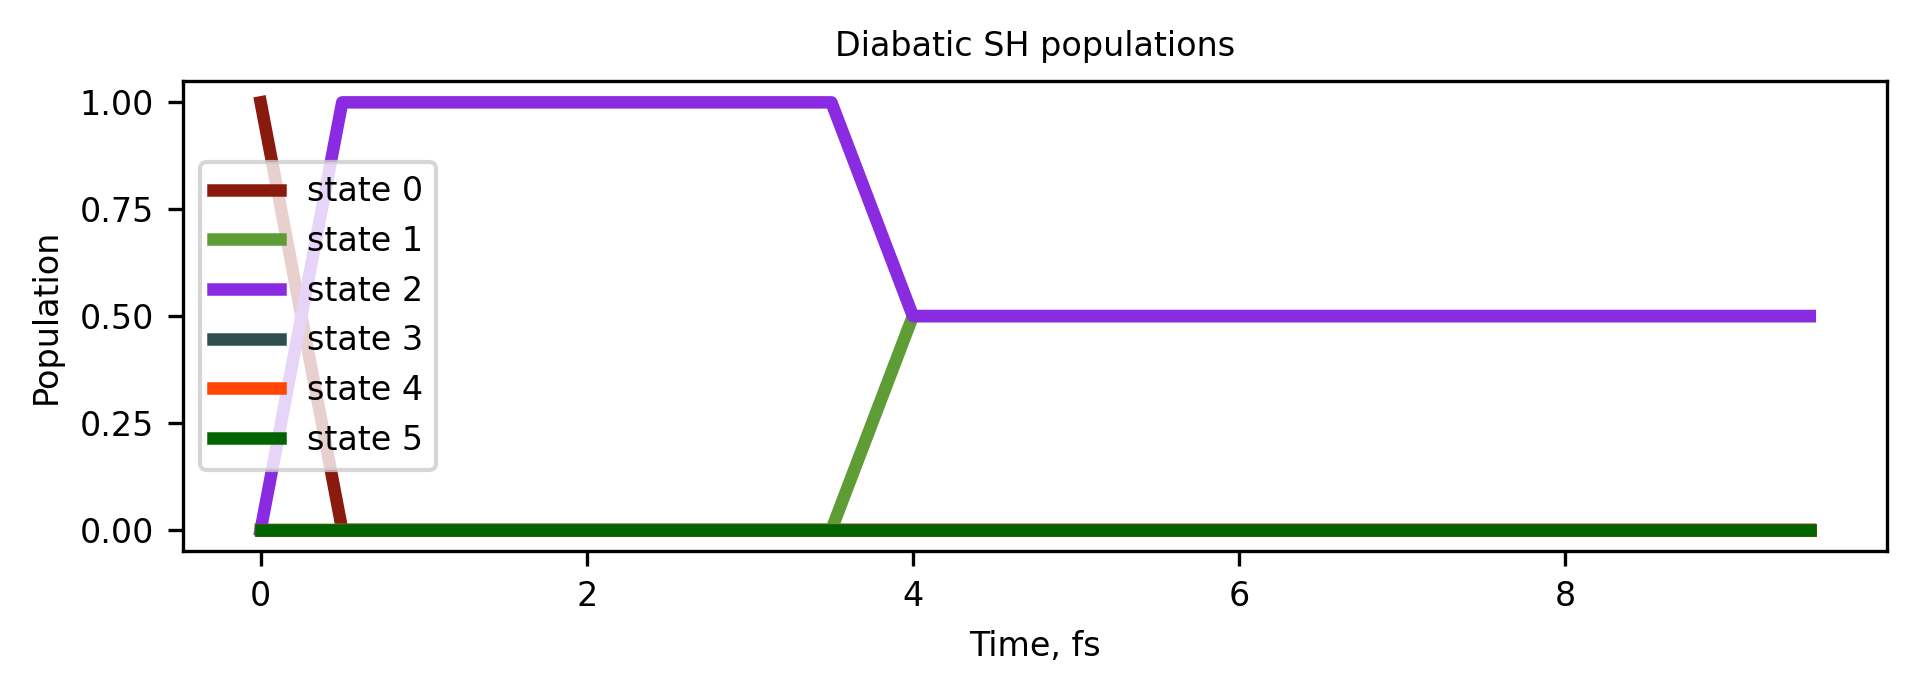

In [24]:
############################################################
### 5. Plot the results - preliminary plotting
############################################################
pref = "FSSH2_"
NSTATES = nstates

NTRAJ = dyn_general["ntraj"]
plot_params = { "prefix":pref, "filename":"mem_data.hdf", "output_level":3,
                "which_trajectories":list(range(NTRAJ)), "which_dofs":[0], "which_adi_states":list(range(NSTATES)), 
                "which_dia_states":list(range(NSTATES)), 
                "frameon":True, "linewidth":3, "dpi":300,
                "axes_label_fontsize":(8,8), "legend_fontsize":8, "axes_fontsize":(8,8), "title_fontsize":8,
                "what_to_plot":["coordinates", "momenta",  "forces", "energies", "phase_space", "se_pop_adi",
                                "se_pop_dia", "sh_pop_adi", "sh_pop_dia" ], 
                "which_energies":["potential", "kinetic", "total"],
                "save_figures":1, "do_show":1, "no_label":1
              }
tsh_dynamics_plot.plot_dynamics(plot_params)